<a href="https://colab.research.google.com/github/Chaitanya15-ai/OIBSIP/blob/main/ChaitanyaSawant_Task3(Cleaning_Data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (48895, 16)

First 5 Rows:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    

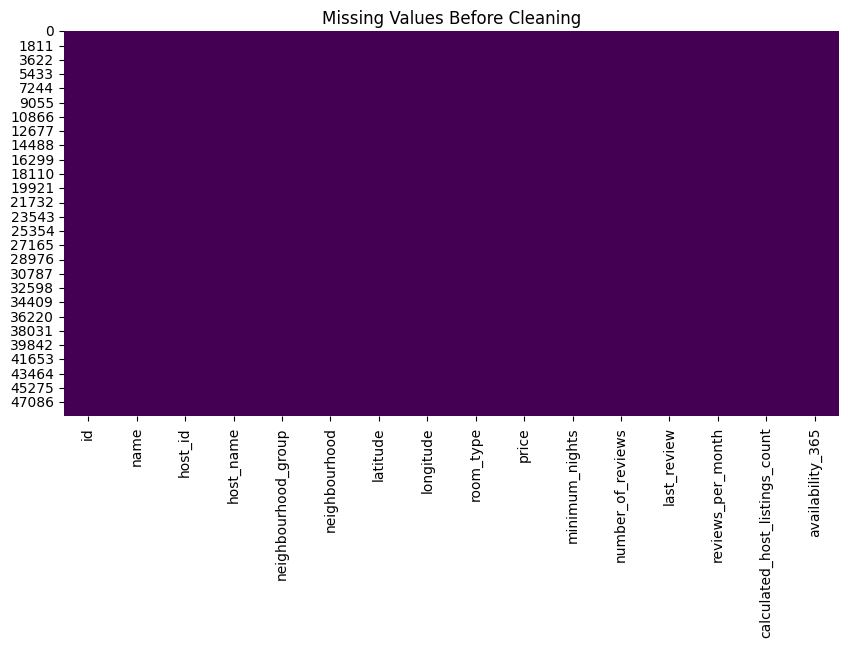

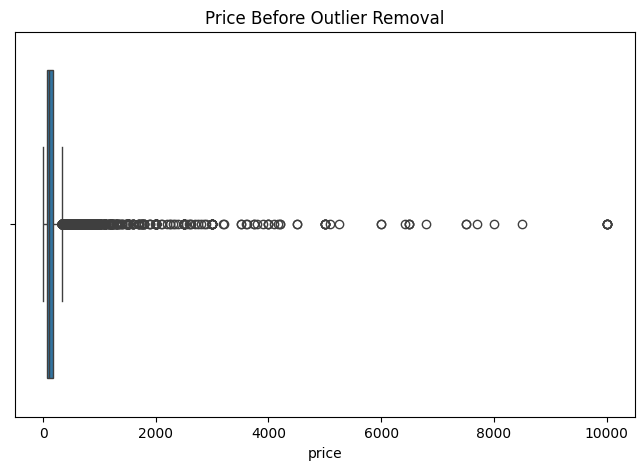

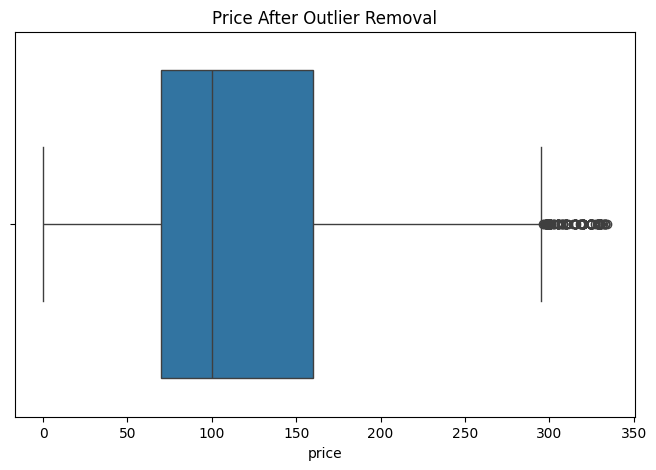

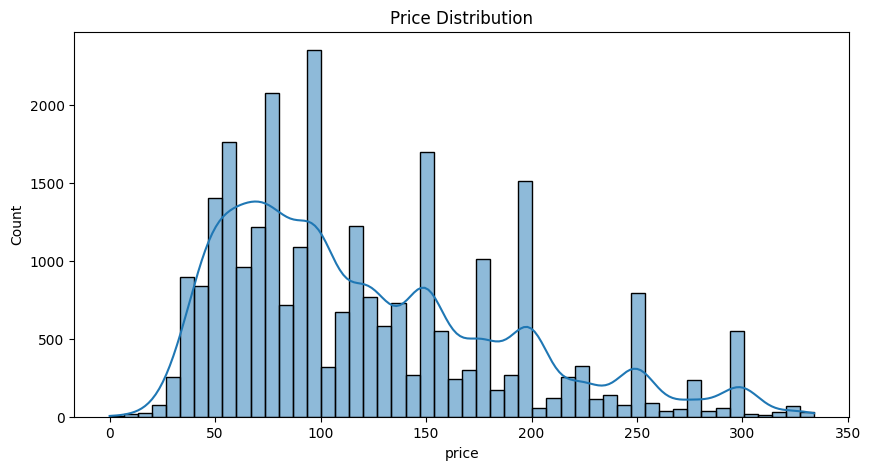

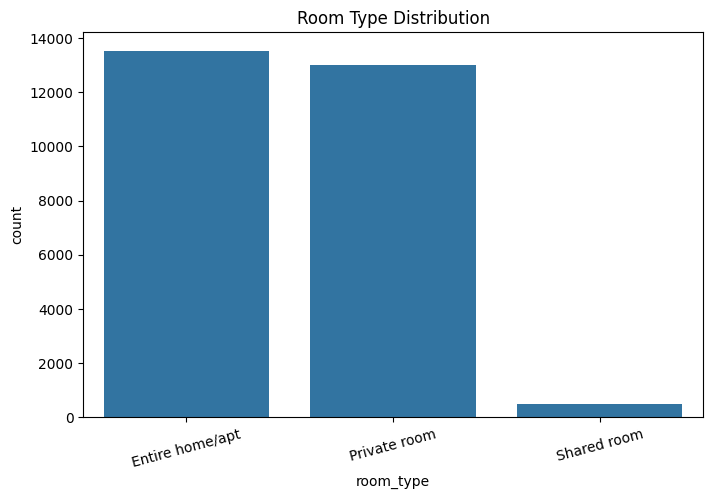

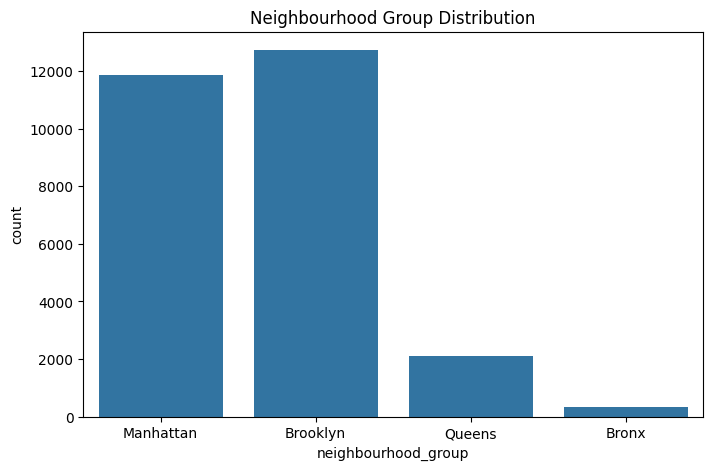

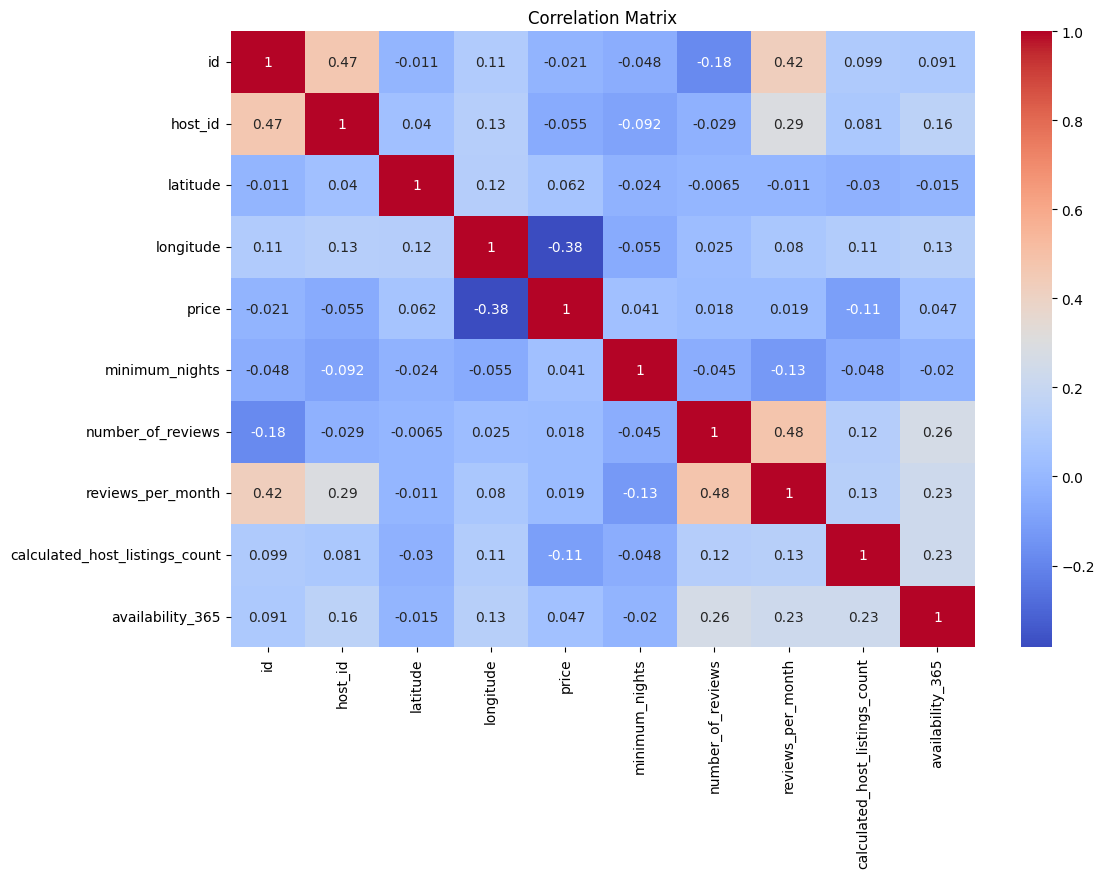


Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 27049 entries, 1 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27049 non-null  int64  
 1   name                            27049 non-null  object 
 2   host_id                         27049 non-null  int64  
 3   host_name                       27049 non-null  object 
 4   neighbourhood_group             27049 non-null  object 
 5   neighbourhood                   27049 non-null  object 
 6   latitude                        27049 non-null  float64
 7   longitude                       27049 non-null  float64
 8   room_type                       27049 non-null  object 
 9   price                           27049 non-null  int64  
 10  minimum_nights                  27049 non-null  int64  
 11  number_of_reviews               27049 non-null  int64  
 12  last_revi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/AB_NYC_2019.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')
df['last_review'] = df['last_review'].fillna('Not Available')
df['reviews_per_month'] = df['reviews_per_month'].fillna(df['reviews_per_month'].median())

duplicates = df.duplicated().sum()
print("\nDuplicate Records:", duplicates)

df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_cleaned = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                  (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nShape After Cleaning:", df_cleaned.shape)

print("\nMissing Values After Cleaning:")
print(df_cleaned.isnull().sum())

df_cleaned.to_csv("AB_NYC_2019_Cleaned.csv", index=False)

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Before Cleaning")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.title("Price Before Outlier Removal")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned['price'])
plt.title("Price After Outlier Removal")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df_cleaned['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='room_type')
plt.title("Room Type Distribution")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='neighbourhood_group')
plt.title("Neighbourhood Group Distribution")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

print("\nFinal Dataset Information:")
print(df_cleaned.info())

print("\nStatistical Summary:")
print(df_cleaned.describe())